# Task 1: Progression / Report of Autoencoder of Quark/Gluon Events

## Introduction:
An autoencoder needed to be trained on a given data set of quark and gluon jets based on three image channels  (ECAL, HCAL and Tracks) with later side by side comparisons of the original and reconstruction from learning

## Initial Plans (standard autoencoder + MSE loss)
Started with standard autoencoder + MSE loss, initally MSE seemed like the right choice because: 

MSE measures the average squared difference between original and reconstructed pixels

The goal is pixel level reconstruction so comparing each pixel directly seemed logical

It is simple and interpretable: a lower number directly means a better reconstruction

## Results / Problems with standard autoencoder + MSE loss

After epoch 1 the loss dropped from 0.001855 to 0.000439, a massive sudden in the moment unexplainable drop

From epoch 2 onwards the loss froze at exactly 0.000439, no further improvement 

The reconstructed images were completely black, the model was outputting near zero values for everything

## REASONING FOR COLLAPSE

Running a quick analysis on the dataset revealed that only 1.56% of pixels are non-zero

The mean value of non-zero pixels after normalization was only 0.003, tiny values even when active. This means 98.44% of the image is black empty space

MSE averages the error across all pixels equally so outputting zeros gives a MSE of roughly 0.003² = 0.000009 per pixel which is nearly perfect

Therefore the model learned that outputting black for everything scores extremely well on MSE without actually reconstructing anything

## Initial fix for collapse ( weighted MSE)

Since MSE treated all pixels equally, the model exploited the zero pixels by making everything black so the fix seemed straightforward: make the non-zero pixels matter more

A weight of 20 was assigned to every non-zero pixel and for the zero pixels a weight of 1 was kept (This meant getting a non-zero pixel wrong was 20 times more costly than getting a zero pixel wrong)

The idea was to make the shortcut of outputting black much more expensive, the model would now be heavily penalised for missing the bright energy deposits

## Result / problem of weighted MSE

Epoch 1 showed genuine learning, the loss dropped steadily from 0.017 down to 0.005 across 1700 batches however at epoch 2 it froze at exactly 0.000907 and stayed there for every single subsequent epoch

The reconstructed images were still completely black so identical to the unweighted MSE collapse (just progressed further before collapse took place)

## Reason of Weighted MSE collapse

The weighting helped slow down the collapse, it took until epoch 2 instead of happening immediately. However the model still found a new equilibrium where outputting near-zero values minimised the weighted loss

The fundamental problem was still there: there was no mechanism forcing the model to produce meaningfully different outputs for different jets

A regular autoencoder compresses to fixed numbers, with no constraints on what those numbers look like. Therefore the encoder could map every single jet to nearly the same 128 numbers, and the decoder could learn to output the same near-zero image for all of them. 

The weighted loss made cheating more expensive but, didn't make it impossible, the model just had to find a slightly less obvious shortcut (essentially the weighted MSE treated the symptom but not the cause)

# Final Fix / implementation

## Variational Autoencoder (VAE) + KL loss term + change in normalisation

The problem was that the autoencoder would turn the images entierly black instead of learning the jet patterns because, that produced highly accurate reconstructions since the original images were compromised of 98.44% black space on average. This is not the desired result, so a model was required that would penalise the: "make everything black strategy" so much that it would have no choice but to learn the actual jet patterns

This was achieved through 3 means:

1. Per jet normalisation, initially global normalisation was present, we divided every pixel in the entire datset by the single largest value across all 139,306 jets. This value happened to be 1.38, so every pixel got divided by 1.38 the problem with this was that the brightest pixels in most jets were nowhere near 1.38, a typical jet's brightest pixel might be 0.004 and after dividing the typical pixel by 1.38 one would get 0.003. Therefore, the non-zero pixels that actually matter ended up as tiny number close to zero so the model could dismiss them since it was making an error of only 0.003 which is essentially nothing.

    This normalisation was changed to per jet normalisation, where instead of one global maximum we normalise each channel of each jet independently which means for each jet we find the maximum value in that specific channel and divide by that. So the brightest pixel in every jet's ECAL, HCAL and tracks channel becomes 1.0. If the model would try to output a zero for a pixel with value 1.0 is is  making an enormous error which would teach it quickly not to do so in turn taking the jets in to account.

2. VAE(Variational Autoencoder), a regular autoencoder would compress each jet to a fixed set of numbers for example 128 exact values, there are no rules what those numbers should look like or how they should relate to each other. The encoder can map every single jet to nearly identical numbers and the decoder can learn to output the same image for all of them. There is nothing to prevent this as could be observed with the all black images.

    How VAE (Variational Autoencoder) fixes this: instead of compressing each jet to 128 exact numbers, the VAE compresses each jet to 128 ranges. Specifically for each slot it produces two things: the mean (midrange) and the Variance (how wide the range is) So for example: instead of saying this jet is exactly 0.3 in slot 1, it would be this jet is somewhere around 0,3 +- 0.1 in slot 1. It then randomly picks a number from the range and passes that to the decoder. 

    Why this matters? Firstly, the decoder never gets the exact same input twice for the same jet, the randomness forces the model to learn how to reconstruct jets from a range of possible inputs rather than just one fixed point. This then almost guarantees that there is no possibility of memorising exact mappings. Secondly, the VAE allows us to use the KL loss term which actually prevents the model from creating an average reconstruction that would fit most jets somewhat well, but would not be precise for any. 

3. KL loss term, The Kl loss term essentially is a mathematical measurment for analysing how different two probability distributions are from each other. In this context it measures how different the learned distribution of representations is from an ideal spread out distribution. A spread out distribution is ideal, as mapping all jets to the same region in latent space causes the encoder to not use all available slots to store information. Which can lead to important features being left out due to lack of space. The Kl loss enforces the use of all the space by directly penalising clustering, whenever representation collapse towards the same region the Kl term increases sharply, adding a large value to the total loss thus forcing the encoder to spread jets across the full latent space. Allowing for more information to be stored and therefore in most cases better reconstructions.


With these three fixes we can finally get some reconstruction results, How will the reconstrcuctions compare to the original? 

4 models have been tested to examine the importance of certain hyperparameters: the models vary via the latent size (128 vs 256) and the implementation of a scheduler (yes, no)

The latent size: accounts for how much information the encoder can store for the reconstruction. 

Idea: The more information it can store the more accurate the representation should be since it has more information to reconstruct it 

The scheduler: automatically reduces the learning rate at set intervals (10 epochs in this case) to prevent model from over correcting 

Idea: The more epochs the model has trained on the more accurate it has become so having a large learning rate later on might prevent the model from finding more fine tuned solutions as it would be taking steps that are too large causing it to overshoot past the optimal point


# Results

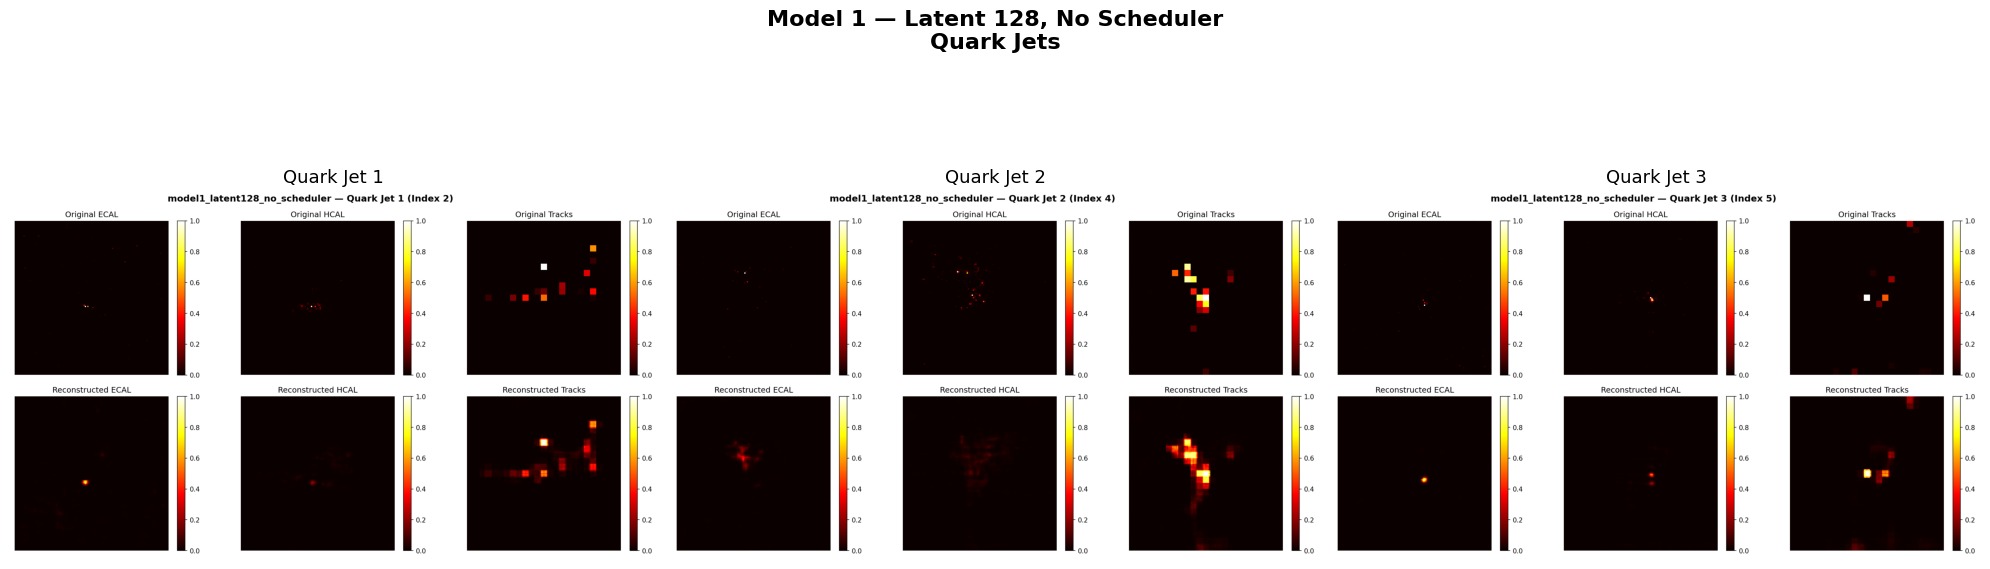

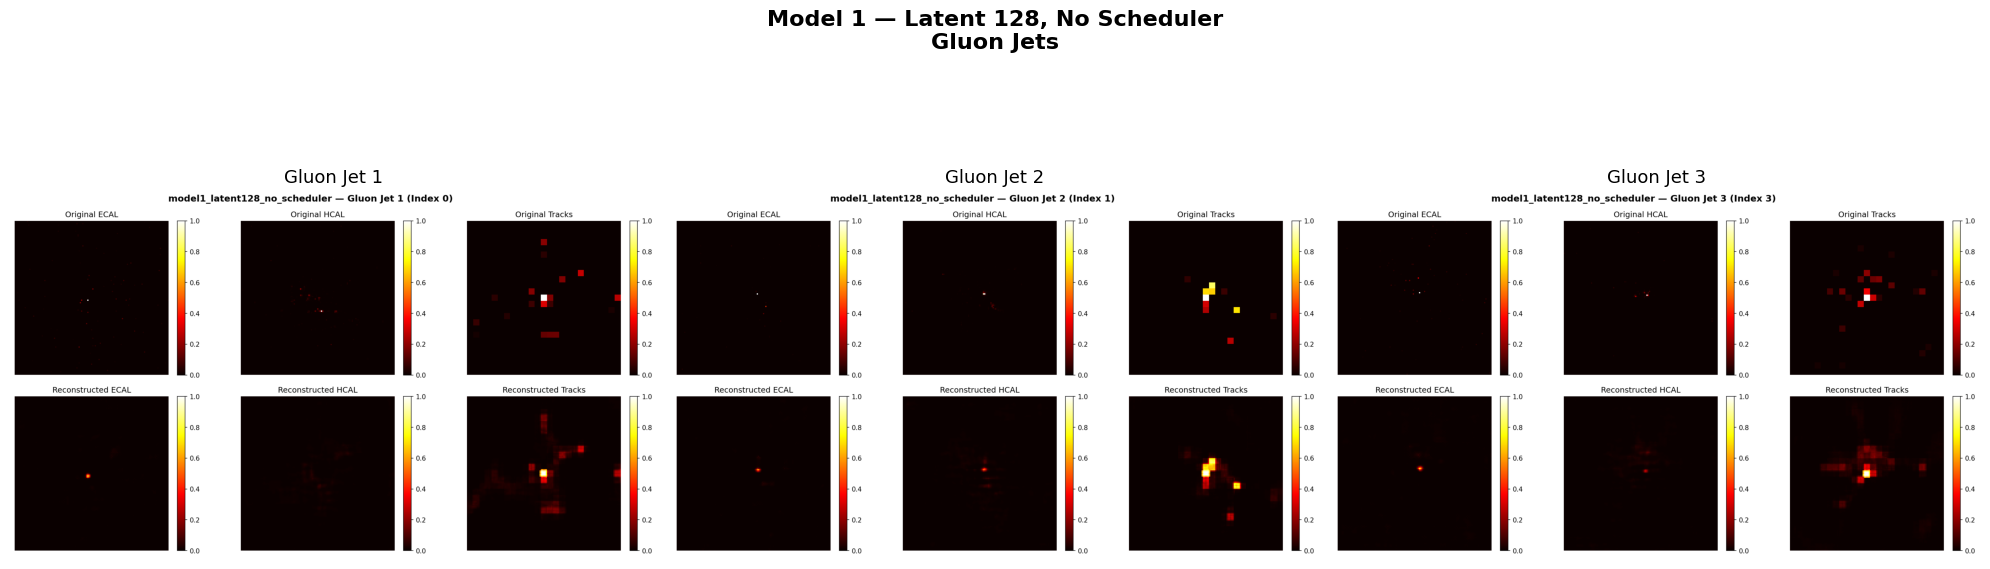

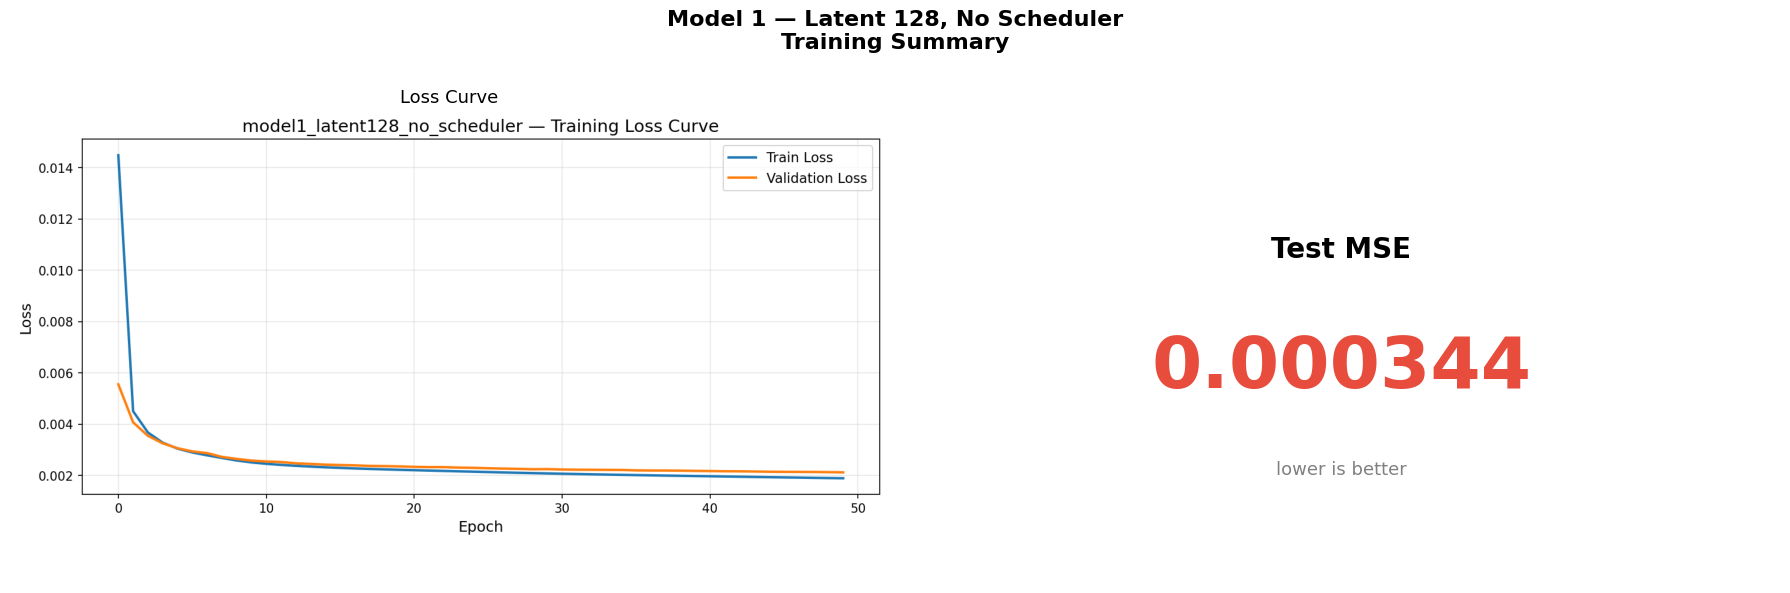

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_path = r"C:\Users\Programmer2\Desktop\manu\results"
model_name = "model1_latent128_no_scheduler"
title = "Model 1 — Latent 128, No Scheduler"
mse = "0.000344"
color = '#e74c3c'

# quarks
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nQuark Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['quark_1', 'quark_2', 'quark_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Quark Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# gluons
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nGluon Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['gluon_1', 'gluon_2', 'gluon_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Gluon Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# loss curve + mse
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{title}\nTraining Summary', fontsize=16, fontweight='bold')
img = mpimg.imread(f'{base_path}\\{model_name}\\loss_curve.png')
axes[0].imshow(img)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].axis('off')
axes[1].axis('off')
axes[1].text(0.5, 0.65, 'Test MSE', ha='center', va='center',
            fontsize=20, fontweight='bold', color='black')
axes[1].text(0.5, 0.42, mse, ha='center', va='center',
            fontsize=52, fontweight='bold', color=color)
axes[1].text(0.5, 0.22, 'lower is better', ha='center', va='center',
            fontsize=13, color='gray')
plt.tight_layout()
plt.show()

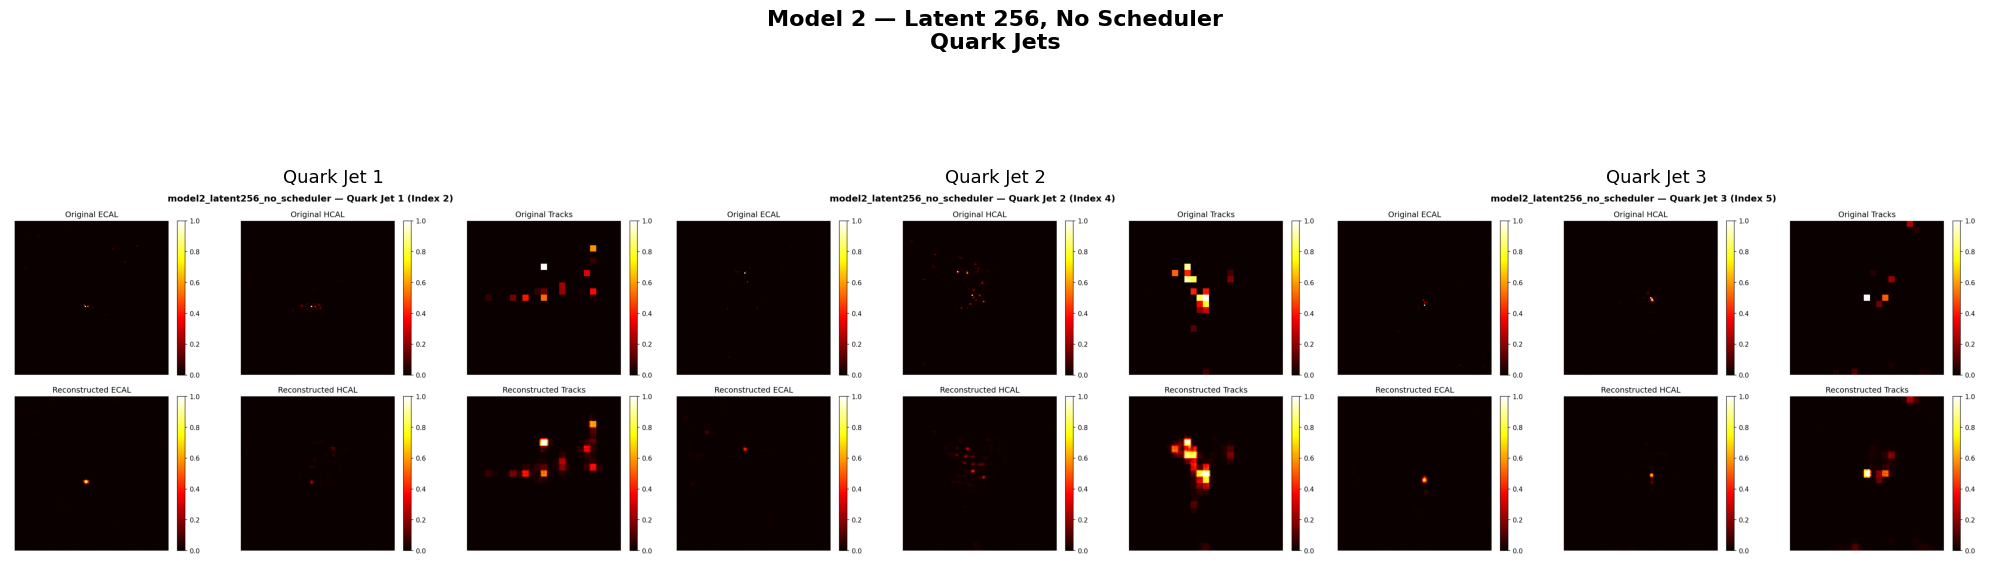

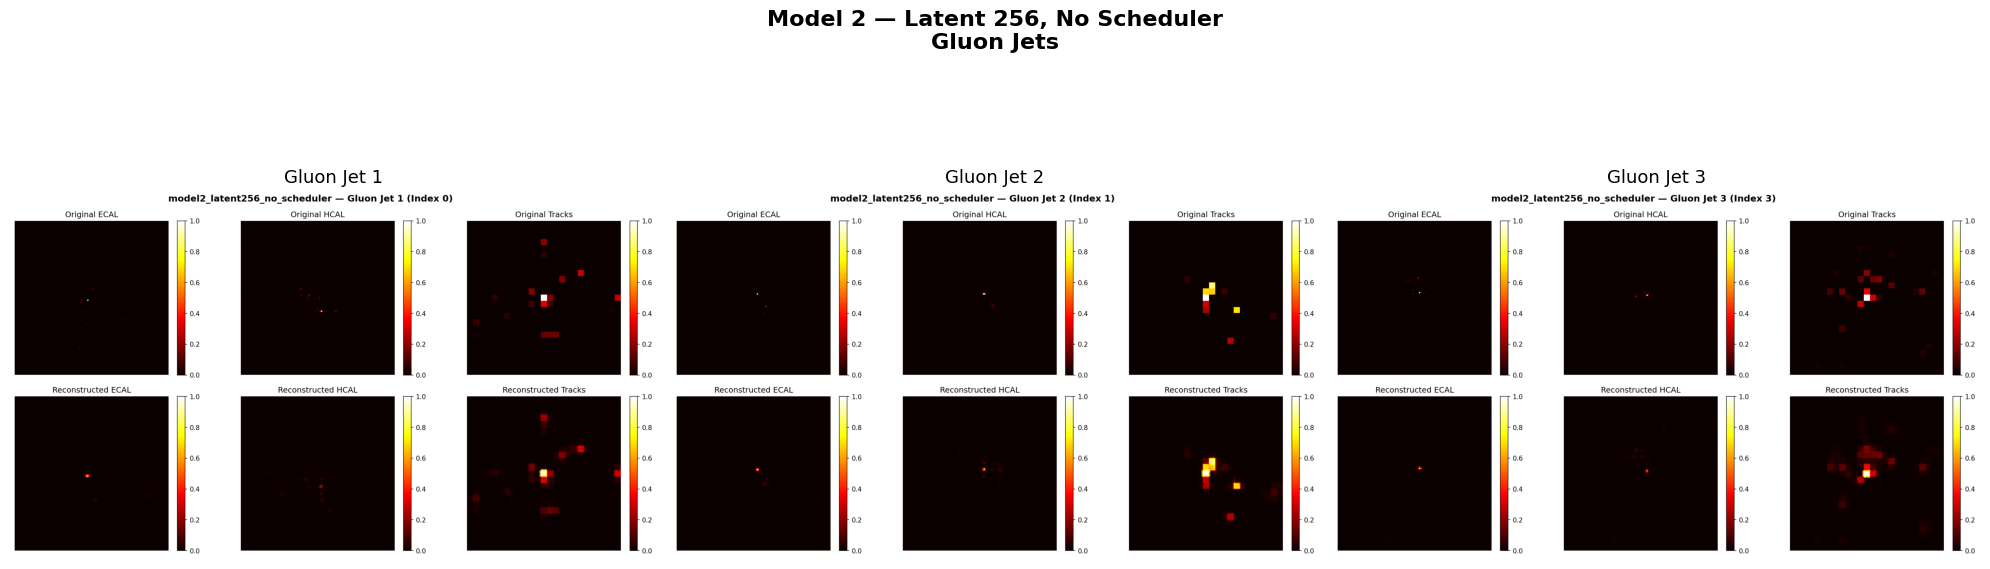

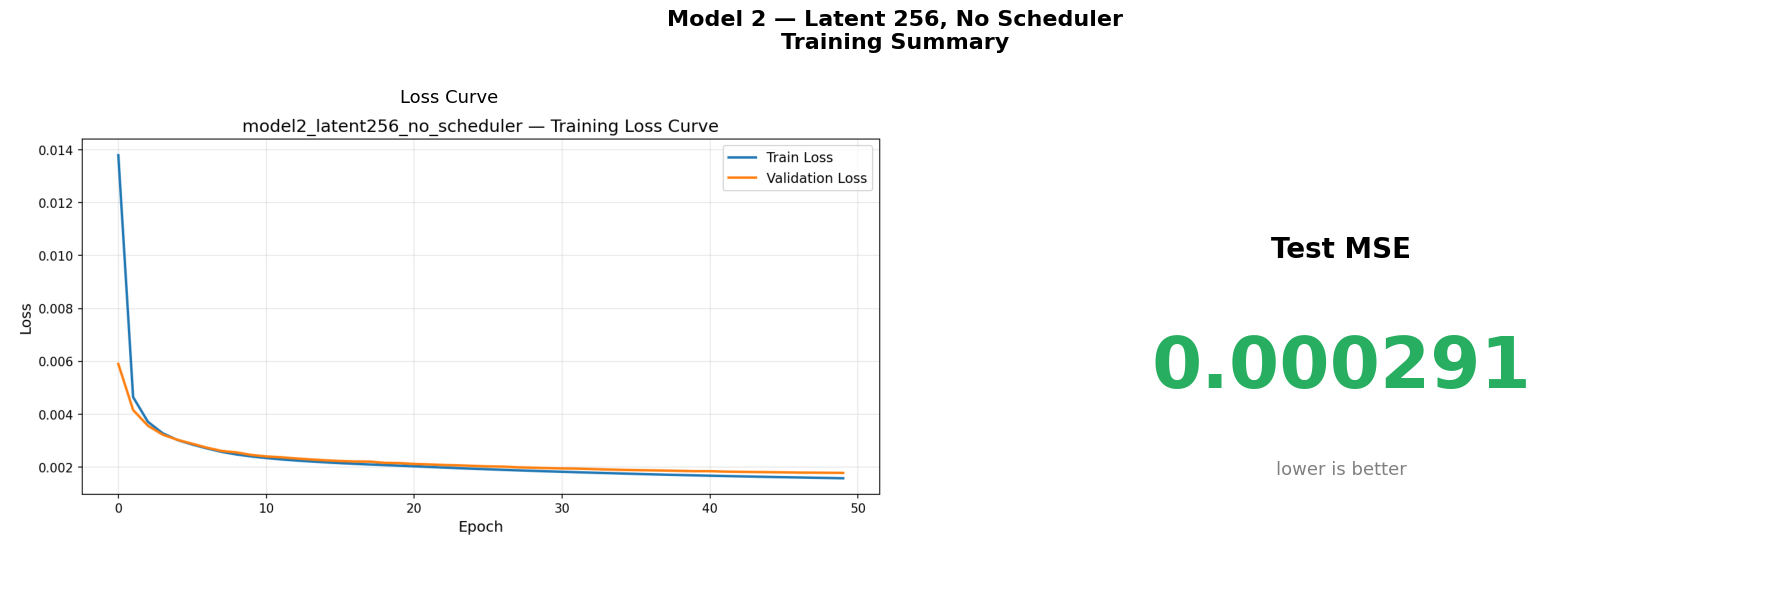

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_path = r"C:\Users\Programmer2\Desktop\manu\results"
model_name = "model2_latent256_no_scheduler"
title = "Model 2 — Latent 256, No Scheduler"
mse = "0.000291"
color = '#27ae60'

# quarks
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nQuark Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['quark_1', 'quark_2', 'quark_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Quark Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# gluons
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nGluon Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['gluon_1', 'gluon_2', 'gluon_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Gluon Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# loss curve + mse
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{title}\nTraining Summary', fontsize=16, fontweight='bold')
img = mpimg.imread(f'{base_path}\\{model_name}\\loss_curve.png')
axes[0].imshow(img)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].axis('off')
axes[1].axis('off')
axes[1].text(0.5, 0.65, 'Test MSE', ha='center', va='center',
            fontsize=20, fontweight='bold', color='black')
axes[1].text(0.5, 0.42, mse, ha='center', va='center',
            fontsize=52, fontweight='bold', color=color)
axes[1].text(0.5, 0.22, 'lower is better', ha='center', va='center',
            fontsize=13, color='gray')
plt.tight_layout()
plt.show()

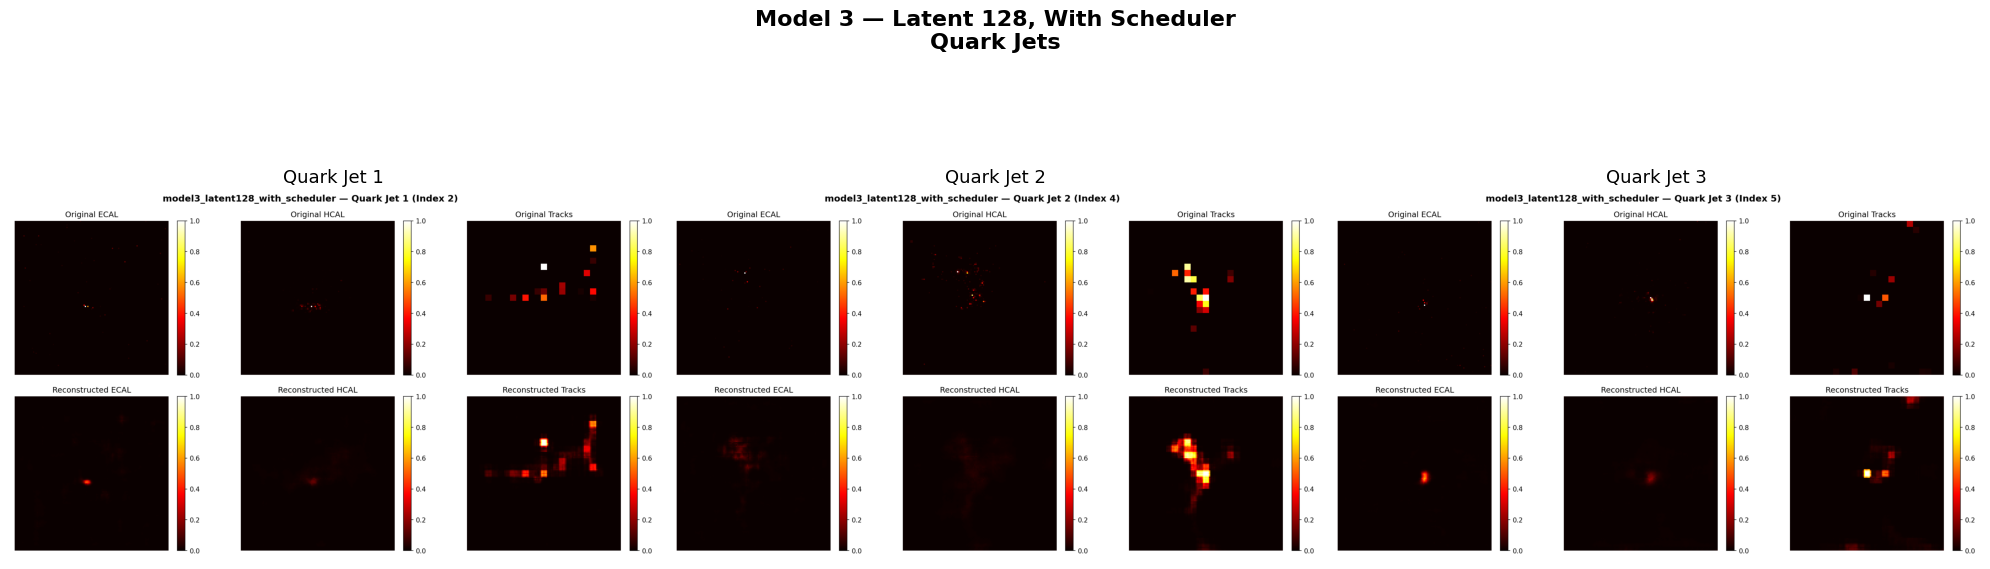

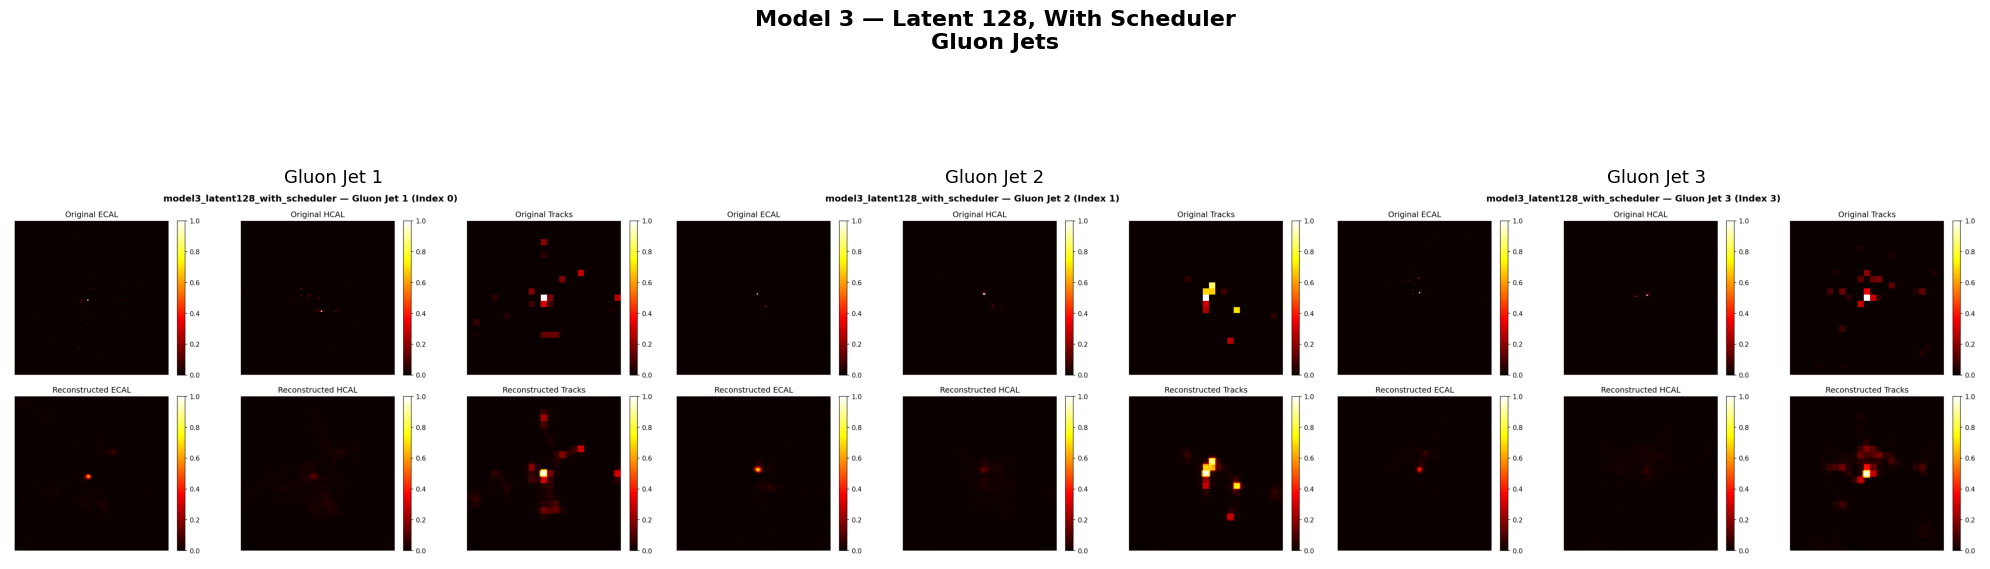

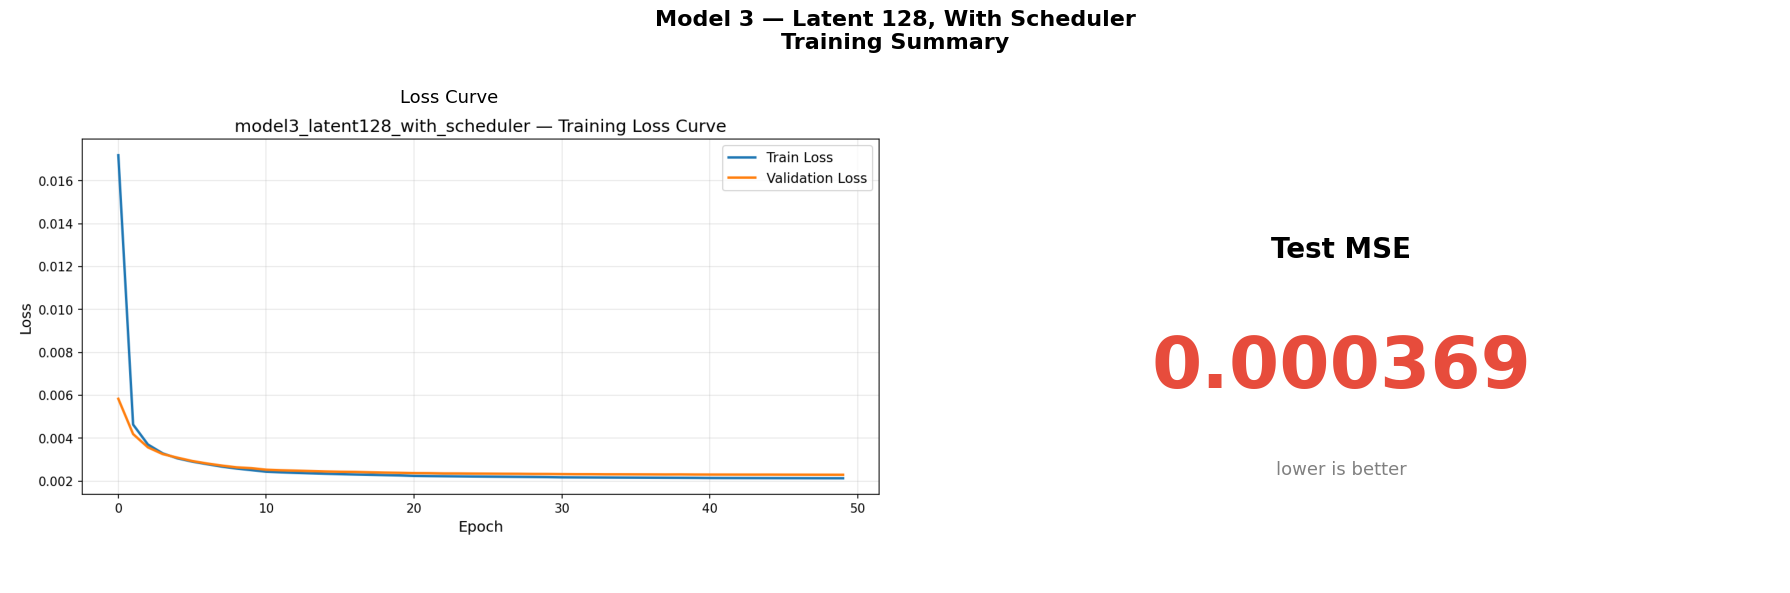

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_path = r"C:\Users\Programmer2\Desktop\manu\results"
model_name = "model3_latent128_with_scheduler"
title = "Model 3 — Latent 128, With Scheduler"
mse = "0.000369"
color = '#e74c3c'

# quarks
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nQuark Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['quark_1', 'quark_2', 'quark_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Quark Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# gluons
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nGluon Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['gluon_1', 'gluon_2', 'gluon_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Gluon Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# loss curve + mse
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{title}\nTraining Summary', fontsize=16, fontweight='bold')
img = mpimg.imread(f'{base_path}\\{model_name}\\loss_curve.png')
axes[0].imshow(img)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].axis('off')
axes[1].axis('off')
axes[1].text(0.5, 0.65, 'Test MSE', ha='center', va='center',
            fontsize=20, fontweight='bold', color='black')
axes[1].text(0.5, 0.42, mse, ha='center', va='center',
            fontsize=52, fontweight='bold', color=color)
axes[1].text(0.5, 0.22, 'lower is better', ha='center', va='center',
            fontsize=13, color='gray')
plt.tight_layout()
plt.show()

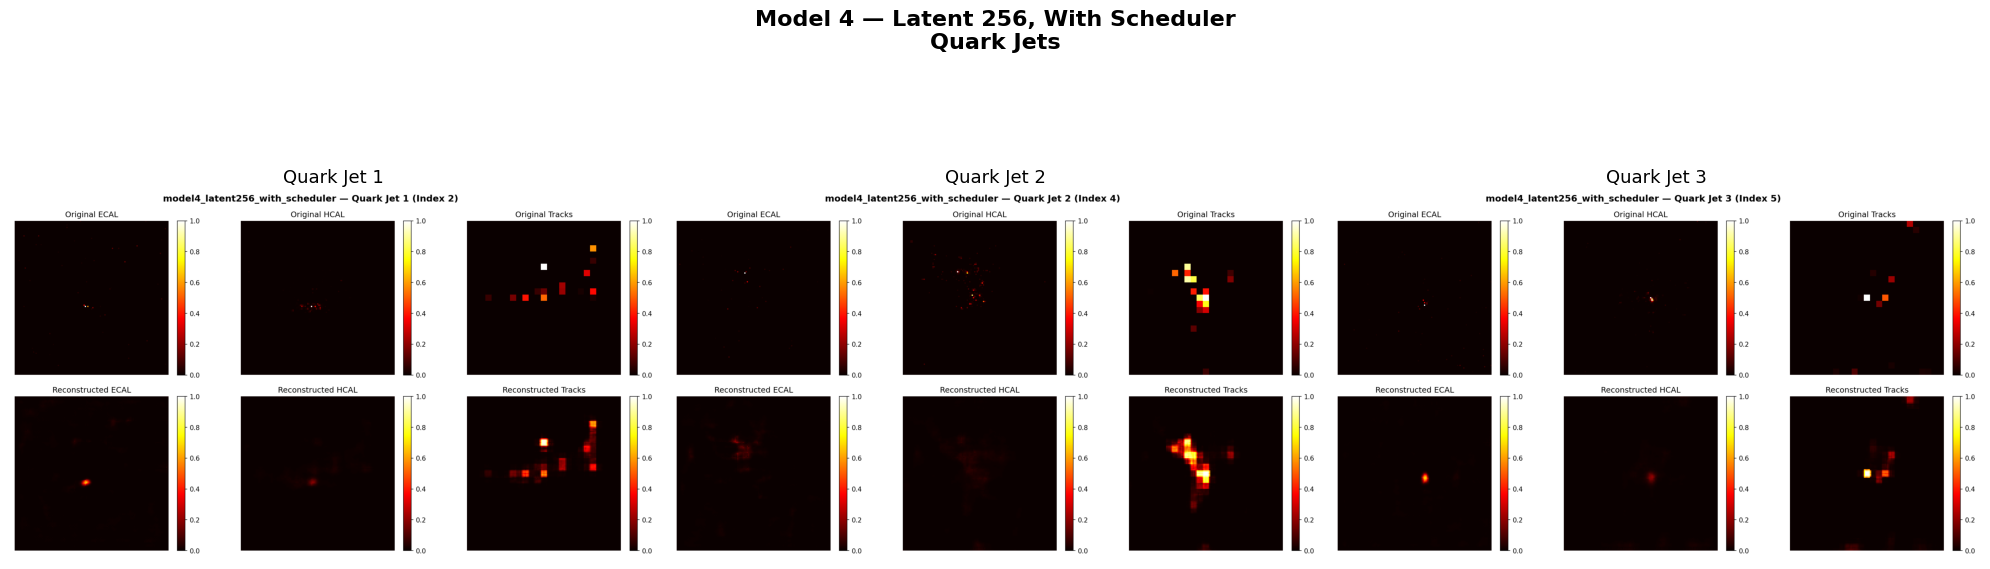

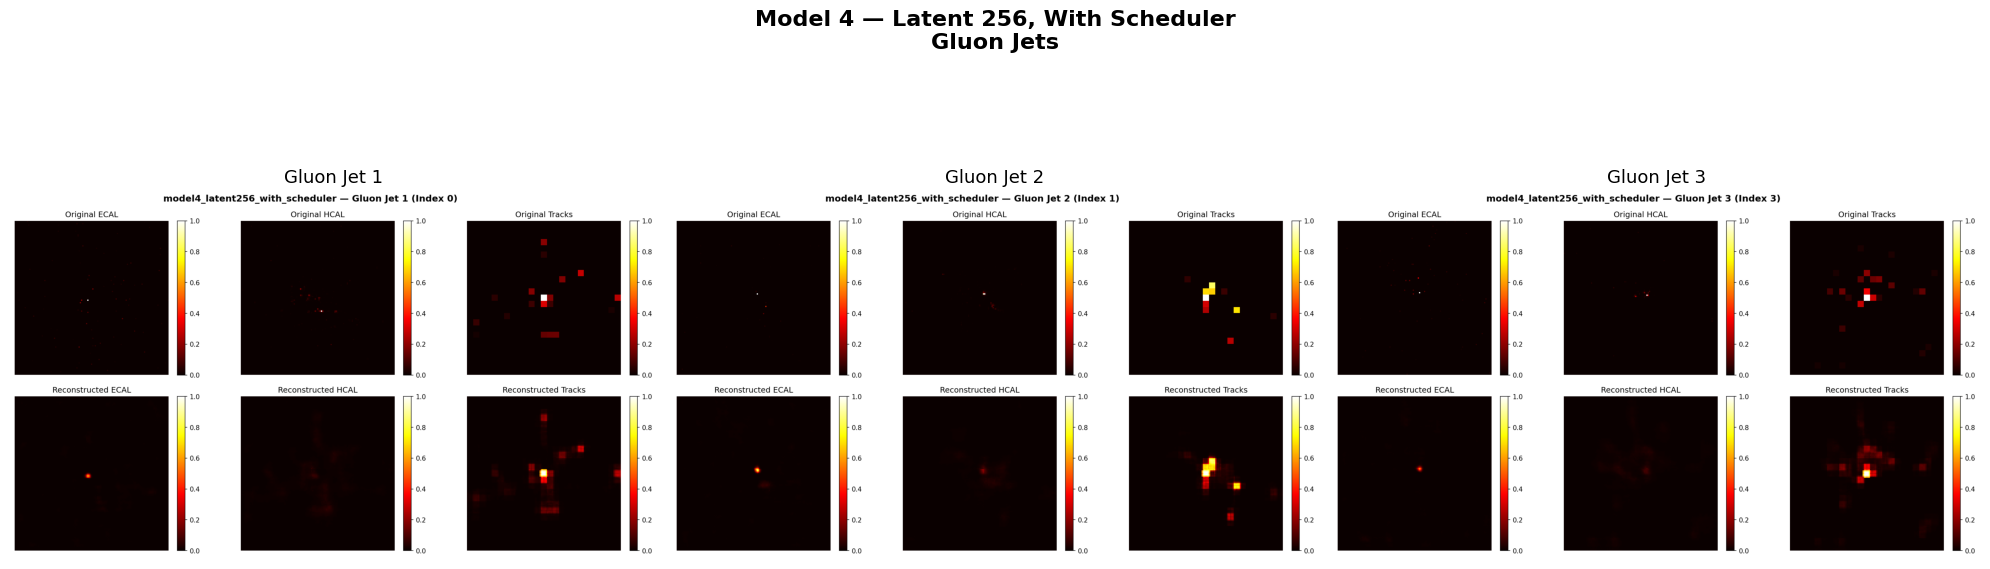

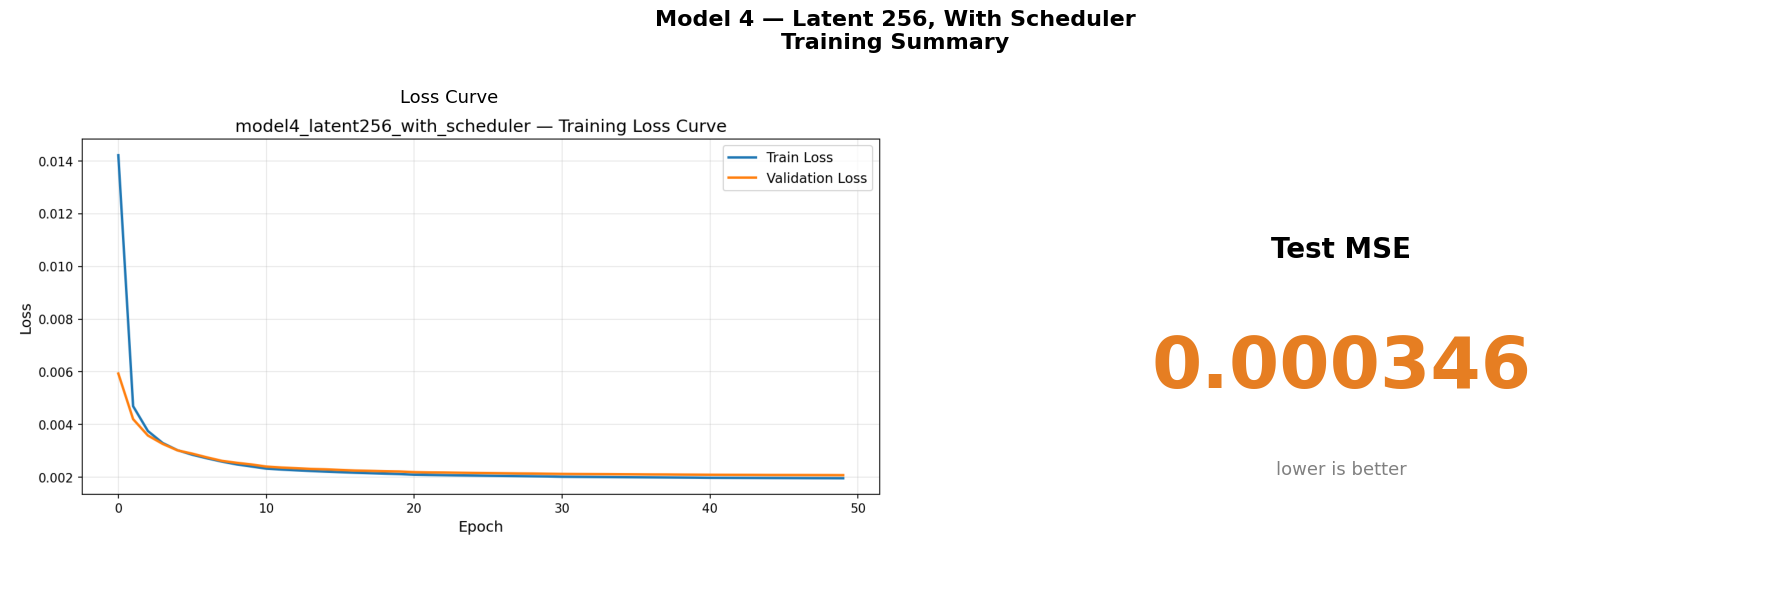

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_path = r"C:\Users\Programmer2\Desktop\manu\results"
model_name = "model4_latent256_with_scheduler"
title = "Model 4 — Latent 256, With Scheduler"
mse = "0.000346"
color = '#e67e22'

# quarks
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nQuark Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['quark_1', 'quark_2', 'quark_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Quark Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# gluons
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'{title}\nGluon Jets', fontsize=16, fontweight='bold')
for i, name in enumerate(['gluon_1', 'gluon_2', 'gluon_3']):
    img = mpimg.imread(f'{base_path}\\{model_name}\\{name}.png')
    axes[i].imshow(img)
    axes[i].set_title(f'Gluon Jet {i+1}', fontsize=13)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# loss curve + mse
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{title}\nTraining Summary', fontsize=16, fontweight='bold')
img = mpimg.imread(f'{base_path}\\{model_name}\\loss_curve.png')
axes[0].imshow(img)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].axis('off')
axes[1].axis('off')
axes[1].text(0.5, 0.65, 'Test MSE', ha='center', va='center',
            fontsize=20, fontweight='bold', color='black')
axes[1].text(0.5, 0.42, mse, ha='center', va='center',
            fontsize=52, fontweight='bold', color=color)
axes[1].text(0.5, 0.22, 'lower is better', ha='center', va='center',
            fontsize=13, color='gray')
plt.tight_layout()
plt.show()

# Final Comments / Further Improvements

## Scheduler not helping

This hyperparameter was not tuned so when one takes into account a pretty conservative baseline learning rate in addition to small step sizes between each learning reduction it is no suprise that it hurt performance rather than improving it. The implementation of this was just a fun test to see how it would affect performance, it was not a signifcant decrease in accuracy but it shows if hyperparamters which in theory should increase accuracy/performance are not implemented properly can lead to the opposite.

## Larger Latent size leading to higher accuracy

It is no suprise that when allowed to use more information the decoder can better reconstruct the jets 

## Further Improvements

Additional convolutional layer:

Adding an additional convolutional layer could further improve performance through giving the encoder one more level of abstraction to work with. A 5th layer would allow it to detect more complex high level patterns and relationships between clusters of energy deposits. In theory this should produce a more informative latent representation which leads to better reconstruction. 

Batch normalisation:

Adding batch normalisation layers between the convolutional layers would stabalise the training by normalising the activations at each layer. This then allows the model to train faster and more reliably usually leading to better performance in of itself however the additional speed could allow for more epochs to be run in the same amount of time so that should increase the performance somewhat even if incremental 

# Final Notes

Total dataset size: 139,306 jets

Training data: 111,444 jets (80%) 
Validation set: 13,931 jets (10%) to prevent overfitting
Test set: 13,931 jets (10%) used for end comparison so no cheating occurs

The best performing model was: model 2 with no scheduler and a latent size of 256. Outpreforming the second best model, model 1 by 15.4% and the worst model, model 3 by 21.1%

Model 2 had:

MSE = 0.000291
Pixel error = √0.000291 = 0.01706

So on average each pixel was reconstructed to within 1.7 percent of its true value on a scale of 0-1

So the reconstruction accuracy was 98.3% accurate at the pixel level on unseen test jets